In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder
from matplotlib.ticker import StrMethodFormatter

In [2]:
# ==========================================
# 1. Loading Full Dataset & Initial Audit
# ==========================================
# Local desktop path
file_path = "/Users/ht/Desktop/Fall_2024/ADTA_5340/group_project/content/state_TX.csv"

print("Loading full dataset...")
# Load full data first as requested
df_full = pd.read_csv(file_path, low_memory=False)

# Check missing values for the entire dataset
print("\n--- Initial Missing Values Audit ---")
print(df_full.isnull().sum())

Loading full dataset...

--- Initial Missing Values Audit ---
activity_year                            0
lei                                      0
derived_msa-md                           0
state_code                               0
county_code                          13019
                                     ...  
ffiec_msa_md_median_family_income        0
tract_to_msa_income_percentage           0
tract_owner_occupied_units               0
tract_one_to_four_family_homes           0
tract_median_age_of_housing_units        0
Length: 99, dtype: int64


In [3]:
# ==========================================
# 2. Column Selection & Filtering
# ==========================================
# Keep only the 23 specific columns you requested
keep_columns = [
    'activity_year', 'derived_msa-md', 'state_code', 'county_code', 
    'census_tract', 'derived_dwelling_category', 'derived_race', 
    'derived_sex', 'loan_amount', 'interest_rate', 'total_loan_costs', 
    'origination_charges', 'discount_points', 'lender_credits', 
    'loan_term', 'property_value', 'total_units', 'income', 
    'debt_to_income_ratio', 'applicant_age', 'tract_population', 
    'ffiec_msa_md_median_family_income', 'tract_median_age_of_housing_units'
]

print(f"\nFiltering dataset to {len(keep_columns)} selected columns...")
df = df_full[keep_columns].copy()


Filtering dataset to 23 selected columns...


In [4]:
# ==========================================
# 3. Data Cleaning & Preprocessing
# ==========================================
print("Cleaning data and handling outliers...")

# Step 3.1: Handle invalid entries [cite: 20-21]
invalid_entries = ['Exempt', 'NA', 'NaN', '8888', 8888, '(Blanks)']
df.replace(invalid_entries, np.nan, inplace=True)

# Step 3.2: Numeric conversion for financial columns [cite: 13-14, 35]
num_cols = [
    'loan_amount', 'interest_rate', 'total_loan_costs', 'origination_charges', 
    'discount_points', 'lender_credits', 'loan_term', 'property_value', 
    'income', 'debt_to_income_ratio', 'tract_population', 
    'ffiec_msa_md_median_family_income', 'tract_median_age_of_housing_units'
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Step 3.3: Handle missing values (Fill NaN with median for numeric) [cite: 18, 35]
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Step 3.4: Filter extreme outliers for better model fit [cite: 243-249]
df = df[(df['loan_amount'] > 5000) & (df['loan_amount'] < 2500000)].copy()
df = df[(df['property_value'] > 5000) & (df['property_value'] < 5000000)].copy()

# Step 3.5: Scaling and Log Transformations [cite: 431-432, 442]
df['income'] = df['income'] * 1000 
df['loan_amount_log'] = np.log1p(df['loan_amount'])
df['property_value_log'] = np.log1p(df['property_value'])

# Step 3.6: Categorical Encoding [cite: 25-32]
le = LabelEncoder()
cat_cols = ['derived_dwelling_category', 'derived_race', 'derived_sex', 'applicant_age', 'county_code']
for col in cat_cols:
    df[f'{col}_encoded'] = le.fit_transform(df[col].astype(str))

Cleaning data and handling outliers...


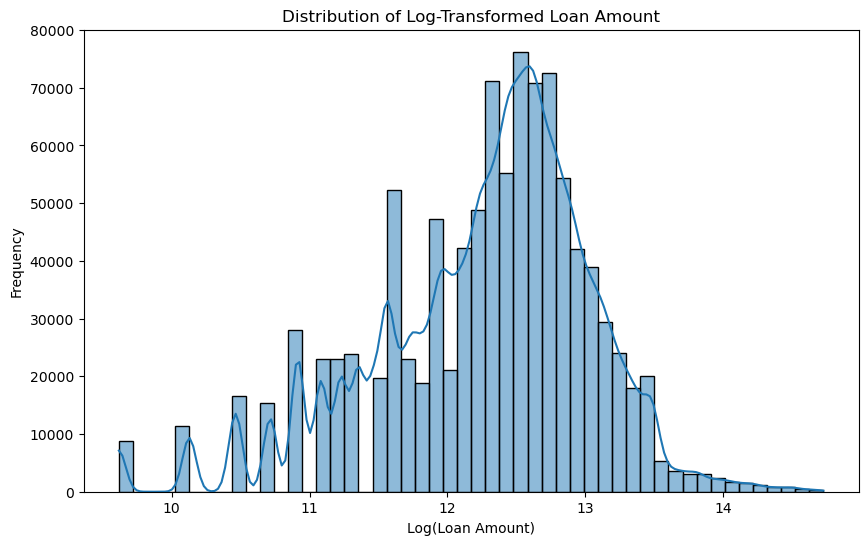

In [11]:
# Create a visualization of the distribution of the target variable (loan_amount_log)
plt.figure(figsize=(10, 6))
sns.histplot(df['loan_amount_log'], bins=50, kde=True)
plt.title('Distribution of Log-Transformed Loan Amount')
plt.xlabel('Log(Loan Amount)')
plt.ylabel('Frequency')
plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.show()

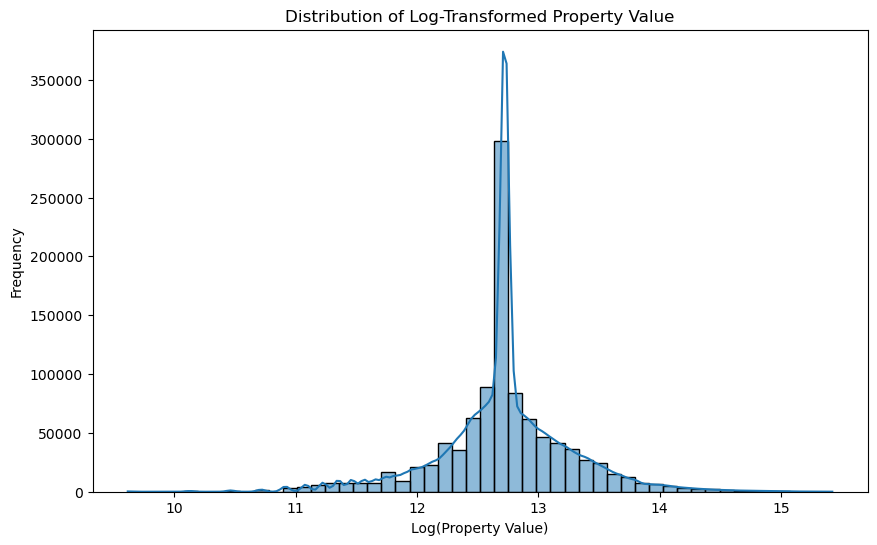

In [13]:
# Create a visualization of the distribution of the property value (property_value_log)
plt.figure(figsize=(10, 6))
sns.histplot(df['property_value_log'], bins=50, kde=True)
plt.title('Distribution of Log-Transformed Property Value')
plt.xlabel('Log(Property Value)')
plt.ylabel('Frequency')
plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.show()

In [8]:
# ==========================================
# 4. Modeling (XGBoost)
# ==========================================
# Select numeric features for training
X = df.select_dtypes(include=[np.number]).drop(['loan_amount', 'loan_amount_log', 'property_value'], axis=1)
y = df['loan_amount_log']

# 80/20 train-test split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training XGBoost on {X_train.shape[0]} records...")
xgb_model = xgb.XGBRegressor(
    n_estimators=500, max_depth=8, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, reg_alpha=15, 
    tree_method='hist', random_state=42, n_jobs=-1
)
xgb_model.fit(X_train, y_train)

Training XGBoost on 816108 records...


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=-1, num_parallel_tree=None, ...)


Final Model R-squared: 0.7041


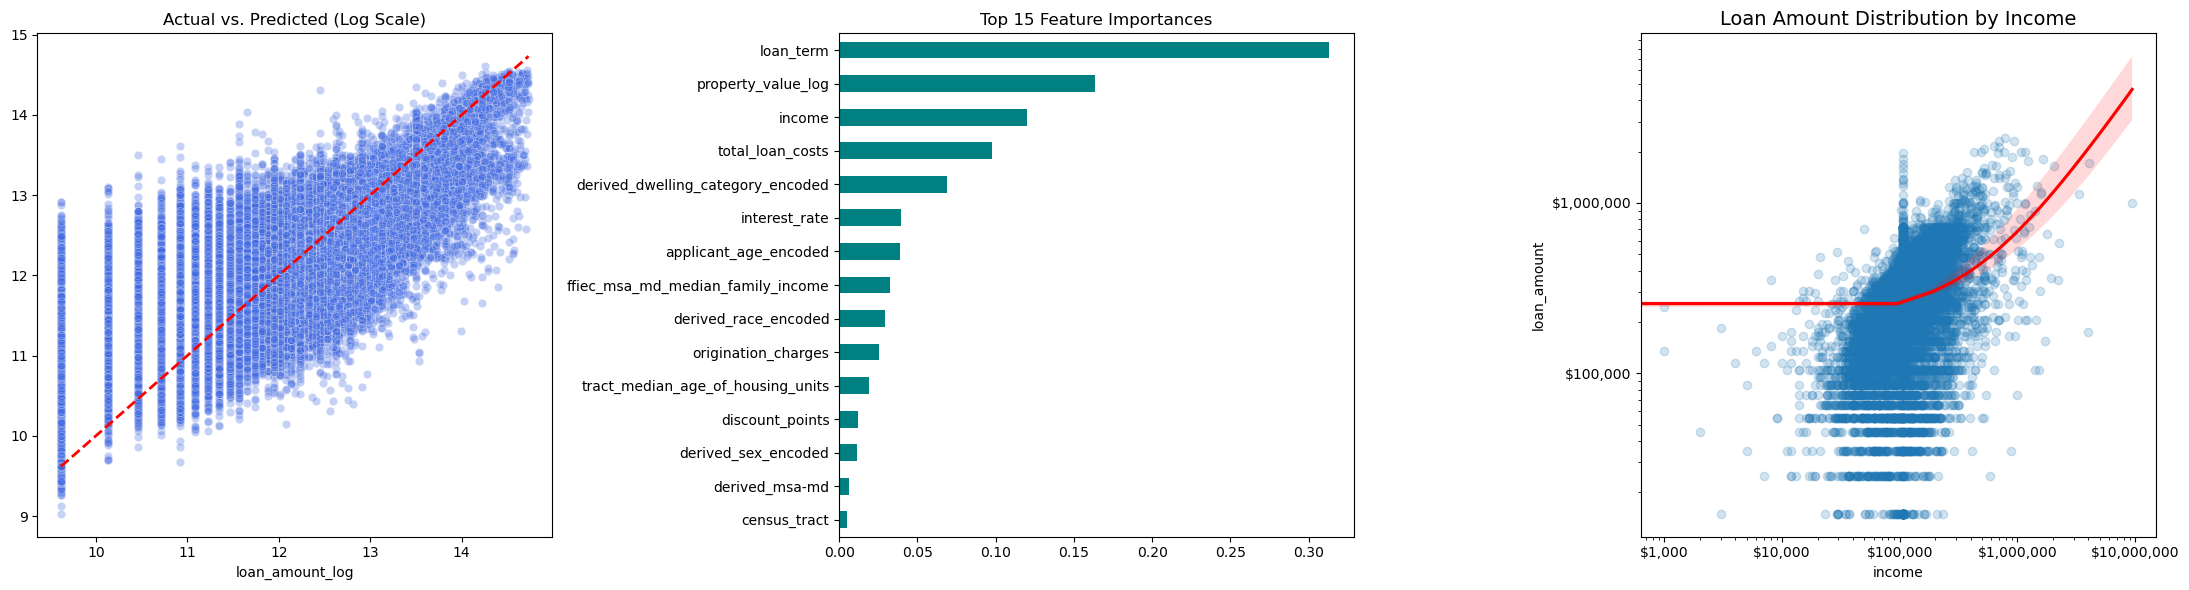

In [10]:
# ==========================================
# 5. Visualizations
# ==========================================
y_pred = xgb_model.predict(X_test)
print(f"\nFinal Model R-squared: {r2_score(y_test, y_pred):.4f}")

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Plot 1: Actual vs. Predicted [cite: 511-512]
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3, ax=axes[0], color='royalblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title('Actual vs. Predicted (Log Scale)')

# Plot 2: Top 15 Feature Importances [cite: 567-572]
pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values().tail(15).plot(kind='barh', ax=axes[1], color='teal')
axes[1].set_title('Top 15 Feature Importances')

# --- Chart 3: Loan Amount Distribution by Income ---
# Purpose: Show the density of loans across different income levels (using 10k sample) 
df_sample = df.sample(n=10000, random_state=42)
sns.regplot(data=df_sample, x='income', y='loan_amount', 
            scatter_kws={'alpha':0.2}, line_kws={'color':'red'}, ax=axes[2])
axes[2].set_xscale('log')
axes[2].set_yscale('log')
axes[2].set_title('Loan Amount Distribution by Income', fontsize=14)
axes[2].xaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
axes[2].yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))

plt.tight_layout()
plt.show()

In [15]:
# ==========================================
# 6. Final Evaluation & Importance
# ==========================================
y_pred = xgb_model.predict(X_test)

print("\n" + "="*40)
print("FINAL PROJECT MODEL RESULTS")
print("="*40)
print(f"R-squared: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE (Log Space): {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

# Map feature importance [cite: 567-572]
importances = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nKey Predictors (Feature Importance):")
print(importances)


FINAL PROJECT MODEL RESULTS
R-squared: 0.7041
RMSE (Log Space): 0.4318

Key Predictors (Feature Importance):
loan_term                            0.313206
property_value_log                   0.163649
income                               0.119724
total_loan_costs                     0.097544
derived_dwelling_category_encoded    0.068885
interest_rate                        0.039432
applicant_age_encoded                0.038812
ffiec_msa_md_median_family_income    0.032325
derived_race_encoded                 0.028946
origination_charges                  0.025435
tract_median_age_of_housing_units    0.019315
discount_points                      0.012235
derived_sex_encoded                  0.011500
derived_msa-md                       0.006475
census_tract                         0.005163
debt_to_income_ratio                 0.004542
lender_credits                       0.003674
county_code                          0.003497
tract_population                     0.003110
county_code_enco